# Trabalho Prático – Estrutura de Dados II (DCA3702)

## Análise Estrutural de Redes Urbanas com OSMnx, NetworkX e Gephi

Este notebook descreve o trabalho prático associado aos conteúdos das ``Semanas 5 e 6`` da disciplina de **Estrutura de Dados II**, com foco em ``Hubs`` e ``Core Decomposition``.

A proposta é utilizar dados reais de redes urbanas extraídas do OpenStreetMap por meio da biblioteca [OSMnx](https://github.com/gboeing/osmnx), realizar análises estruturais com [NetworkX](https://networkx.org/en/) e produzir visualizações avançadas no [Gephi](https://gephi.org/).

## 1. Objetivo

O objetivo deste trabalho é aplicar conceitos de grafos em uma rede real, interpretando a malha viária de uma cidade ou bairro como um grafo.

Os alunos deverão identificar e analisar:

- nós centrais da rede, também chamados de ``hubs``;
- regiões estruturalmente densas por meio da decomposição ``k-core``;
- pontos críticos de conexão e fluxo usando métricas de centralidade;
- diferenças entre a visualização geográfica da rede e a visualização estrutural baseada em layouts de força.

> A proposta **não é apenas executar bibliotecas**, mas compreender como estruturas de dados modelam sistemas reais.

## 2. Problema norteador

Cada grupo deverá responder à seguinte questão:

> **Quais são os elementos estruturais mais importantes da malha viária analisada e como diferentes métricas de grafos, como grau, centralidade e k-core, ajudam a caracterizá-los?**

A análise deve ir além da apresentação de gráficos. Espera-se uma interpretação crítica dos resultados obtidos.

## 3. Escolha da região de estudo

Cada grupo deverá escolher uma cidade, bairro ou região urbana. Exemplos possíveis:

- Natal/RN;
- Ponta Negra;
- Lagoa Nova;
- Mossoró;
- João Pessoa;
- Recife;
- outra região escolhida pelo grupo.

A escolha deve ser justificada brevemente no `README.md` que acompanhará o repositório do projeto no Github.

>  🚨🚨🚨 Recomenda-se evitar regiões grandes demais, pois isso pode tornar o processamento mais lento e dificultar a interpretação visual.

## 4. Etapa 1 – Construção do grafo com OSMnx

O grupo deverá utilizar a biblioteca **OSMnx** para baixar a rede viária da região escolhida.

A rede deverá ser obtida preferencialmente com:

```python
network_type="drive"
```


O grafo deve representar:

- **nós**: interseções ou pontos relevantes da malha viária;
- **arestas**: vias ou segmentos de ruas.

Cada nó extraído pelo OSMnx possui atributos geográficos importantes:

- `x`: longitude;
- `y`: latitude.

Esses atributos serão usados posteriormente para visualização geográfica no Gephi.

In [1]:
# Load the urban drive network for the chosen region using OSMnx.
# Each node is a street intersection; each edge is a road segment.

!pip install osmnx
import os

import osmnx as ox
import networkx as nx

os.makedirs("outputs", exist_ok=True)

place = "Jucurutu, Rio Grande do Norte, Brazil"

G = ox.graph_from_place(place, network_type="drive")

print(G)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


MultiDiGraph with 963 nodes and 2487 edges
Number of nodes: 963
Number of edges: 2487


## 5. Etapa 2 – Análise estrutural com NetworkX

Após a construção do grafo, o grupo deverá calcular métricas estruturais usando **NetworkX**.

### Métricas obrigatórias

O trabalho deve conter, **no mínimo**:

1. grau dos nós;
2. distribuição de grau;
3. identificação dos nós com maior grau, isto é, hubs;
4. betweenness centrality;
5. closeness centrality;
6. core number;
7. análise do k-core da rede.

### Atenção

Algumas métricas podem exigir a conversão do grafo para uma versão não direcionada ou simplificada. O grupo deve explicar as escolhas feitas.

In [2]:
# Graph variants:
# - G_undirected: OSMnx-compatible MultiGraph used for the final GraphML export.
# - G_simple:     simple undirected Graph used for algorithms that require no
#                 parallel edges or self-loops, such as k-core decomposition.
# The OSMnx graph is originally a MultiDiGraph (multi = parallel edges allowed,
# Di = directed). For urban structural analysis we treat connectivity as
# bidirectional and drop multi-edges/self-loops for algorithmic correctness.

G_undirected = ox.convert.to_undirected(G)
G_simple = nx.Graph(G_undirected)
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

print(
    f"Simple undirected graph: "
    f"{G_simple.number_of_nodes()} nodes, "
    f"{G_simple.number_of_edges()} edges"
)


Simple undirected graph: 963 nodes, 1278 edges


In [3]:
# Node degree and the top 10 hubs.
# In a road network the degree of an intersection is the number of street
# segments meeting at it.

from collections import Counter

degree_dict = dict(G_simple.degree())

top_degree = sorted(degree_dict.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 nodes by degree (hubs):")
for node, deg in top_degree:
    print(f"  {node}: degree {deg}")


Top 10 nodes by degree (hubs):
  5174985973: degree 5
  5174985974: degree 5
  2050103452: degree 4
  2300061541: degree 4
  2853739659: degree 4
  2853739661: degree 4
  2853739664: degree 4
  2853739665: degree 4
  2853739667: degree 4
  2853739669: degree 4


Degree distribution:
  degree 1: 233 nodes
  degree 2: 24 nodes
  degree 3: 551 nodes
  degree 4: 153 nodes
  degree 5: 2 nodes


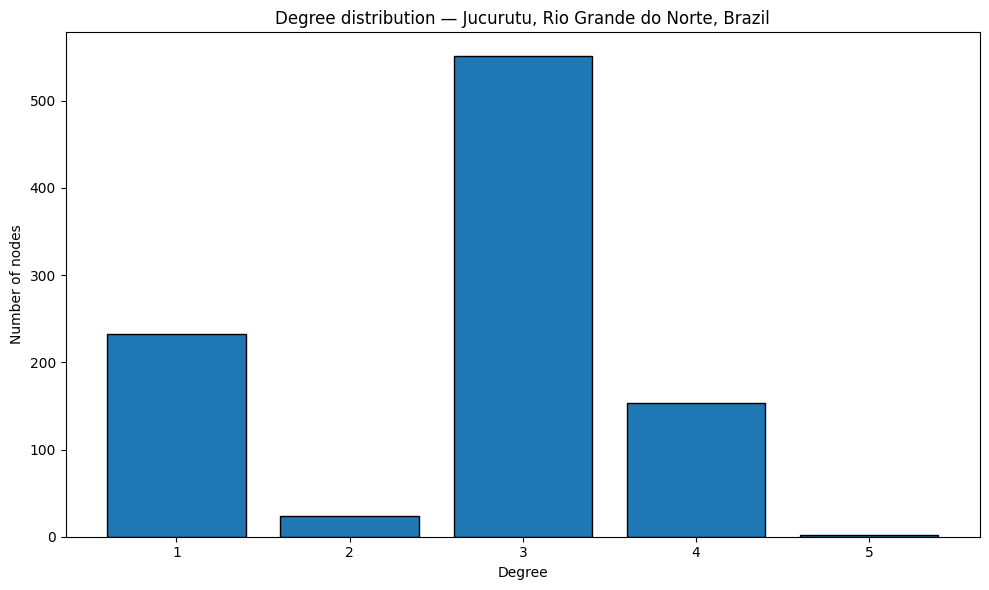

In [4]:
# Degree distribution: number of nodes per degree value.
# Road networks typically have a very narrow degree range (most intersections
# connect 3 or 4 streets), in contrast to scale-free networks such as the web,
# where a heavy tail of high-degree hubs dominates.

import matplotlib.pyplot as plt

degree_counts = Counter(degree_dict.values())

print("Degree distribution:")
for deg in sorted(degree_counts):
    print(f"  degree {deg}: {degree_counts[deg]} nodes")

plt.figure(figsize=(10, 6))
plt.bar(degree_counts.keys(), degree_counts.values(), edgecolor="black")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title(f"Degree distribution — {place}")
plt.tight_layout()
plt.savefig("outputs/degree_distribution.png", dpi=150)
plt.show()


In [5]:
# Betweenness centrality: fraction of all-pairs shortest paths that pass
# through each node. High betweenness reveals routing bottlenecks — nodes the
# network depends on to move traffic between distant regions. Cost is roughly
# O(V*E); on a small town graph this runs in seconds.

betweenness = nx.betweenness_centrality(G_simple, normalized=True)

top_btw = sorted(betweenness.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 nodes by betweenness centrality:")
for node, val in top_btw:
    print(f"  {node}: {val:.6f}")


Top 10 nodes by betweenness centrality:
  7656057383: 0.463844
  6404307217: 0.403419
  7655540958: 0.392816
  7656057330: 0.390114
  6404307216: 0.386108
  2050161742: 0.383905
  4846323093: 0.372785
  4846323721: 0.367213
  2117186598: 0.350255
  7388615782: 0.348764


In [6]:
# Closeness centrality: inverse of the mean shortest-path distance from the
# node to every other reachable node. High closeness means the node is, on
# average, near every other point of the network.

closeness = nx.closeness_centrality(G_simple)

top_cls = sorted(closeness.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 nodes by closeness centrality:")
for node, val in top_cls:
    print(f"  {node}: {val:.6f}")


Top 10 nodes by closeness centrality:
  7655540958: 0.059774
  4846323721: 0.059390
  4846323093: 0.059091
  6404307216: 0.058997
  7388615782: 0.058659
  2050161742: 0.058296
  2117186598: 0.058232
  7654778139: 0.057865
  7656057330: 0.057736
  12182410084: 0.057667


Maximum core number (k_max): 2
Core-number distribution:
  k = 1: 287 nodes
  k = 2: 676 nodes

Nodes in the 2-core (main core): 676


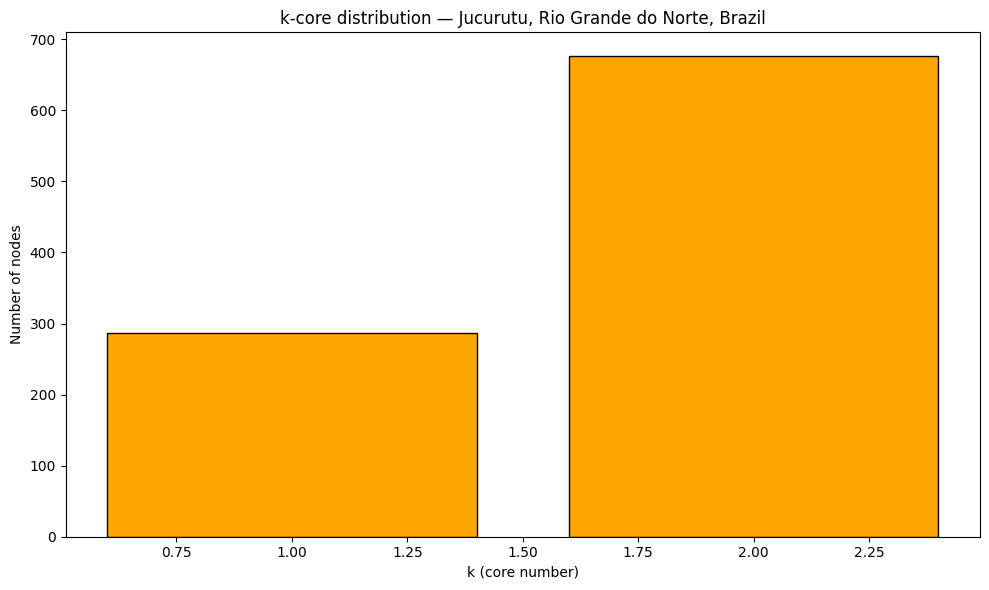

In [7]:
# k-core decomposition: peeling algorithm that iteratively removes nodes with
# degree < k until only nodes belonging to the densest substructure of order k
# remain. The core number of a node is the maximum k such that the node still
# belongs to the k-core. The main core is the subgraph induced by all nodes
# with core number equal to k_max.

core_number = nx.core_number(G_simple)
max_core = max(core_number.values())
print(f"Maximum core number (k_max): {max_core}")

core_counts = Counter(core_number.values())
print("Core-number distribution:")
for k in sorted(core_counts):
    print(f"  k = {k}: {core_counts[k]} nodes")

main_core_nodes = [n for n, c in core_number.items() if c == max_core]
print(f"\nNodes in the {max_core}-core (main core): {len(main_core_nodes)}")

plt.figure(figsize=(10, 6))
plt.bar(core_counts.keys(), core_counts.values(), edgecolor="black", color="orange")
plt.xlabel("k (core number)")
plt.ylabel("Number of nodes")
plt.title(f"k-core distribution — {place}")
plt.tight_layout()
plt.savefig("outputs/core_distribution.png", dpi=150)
plt.show()


### Compiling Network Metrics
Consolidating the calculated metrics into a single DataFrame.

In [8]:
import pandas as pd

network_stats = pd.DataFrame({
    'degree': pd.Series(degree_dict),
    'betweenness': pd.Series(betweenness),
    'closeness': pd.Series(closeness),
    'k_core': pd.Series(core_number)
})

network_stats.head()

,degree,betweenness,closeness,k_core
352698369,1,0.000000,0.035381,1
1834844215,3,0.094338,0.037967,2
2050102272,2,0.000000,0.043277,2
2050103452,4,0.004096,0.045203,2
2050103897,3,0.000042,0.043302,2


### Geographic Mapping
Visualizing the municipality boundaries and the raw street layout.

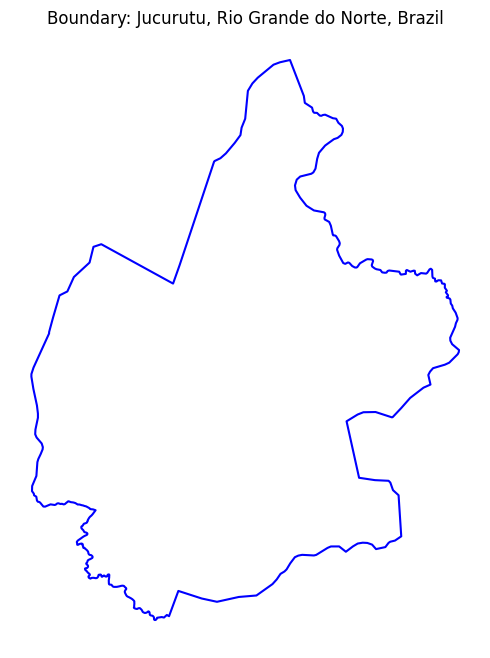

In [9]:
city_boundary = ox.geocode_to_gdf(place)

fig, ax = plt.subplots(figsize=(8, 8))
city_boundary.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1.5)
plt.title(f"Boundary: {place}")
plt.axis("off")

plt.savefig("outputs/city_limits.png", dpi=300, bbox_inches='tight')
plt.show()

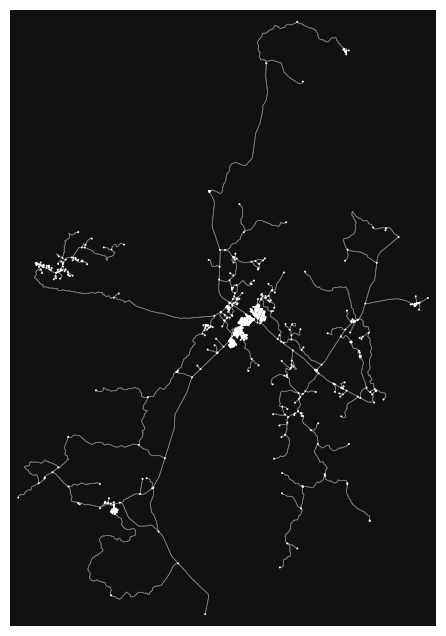

In [10]:
fig, ax = ox.plot_graph(
    G, 
    node_size=2, 
    edge_color="gray", 
    edge_linewidth=0.5,
    show=True, 
    save=True, 
    filepath="outputs/base_network.png", 
    dpi=300
)

### Highlighting Critical Hubs
Plotting the network emphasizing the top 10 nodes with the highest betweenness centrality.

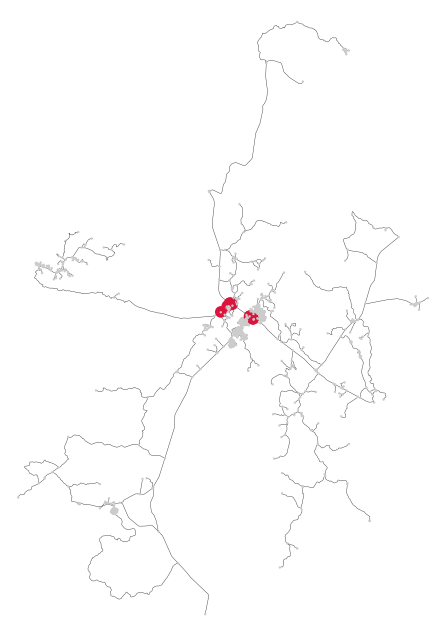

In [11]:
top_bottlenecks = network_stats.nlargest(10, 'betweenness').index

n_colors = ['crimson' if n in top_bottlenecks else '#cccccc' for n in G_undirected.nodes()]
n_sizes = [70 if n in top_bottlenecks else 3 for n in G_undirected.nodes()]

fig, ax = ox.plot_graph(
    G_undirected,
    node_color=n_colors,
    node_size=n_sizes,
    node_zorder=2,
    edge_color="#333333",
    edge_linewidth=0.3,
    bgcolor="white",
    show=True,
    save=True,
    filepath="outputs/critical_hubs.png",
    dpi=300
)

## 6. Questões analíticas obrigatórias

O grupo deverá responder explicitamente às seguintes perguntas:

1. Os nós com maior grau coincidem com os nós de maior betweenness?
2. O núcleo identificado pelo k-core coincide com os principais hubs?
3. O que a métrica de betweenness revela que o grau não revela?
4. O que muda quando a rede é analisada em sua posição geográfica real e quando é analisada por um layout estrutural?
5. Existem regiões críticas para mobilidade urbana na área analisada?
6. A rede parece homogênea ou apresenta concentração estrutural?
7. Os resultados obtidos fazem sentido considerando o conhecimento urbano da região escolhida?

Essas respostas devem aparecer no `README.md`, no notebook e no vídeo (sim, a apresentação será assíncrona :-).

## 7. Etapa 3 – Exportação do grafo para o Gephi

O grafo deverá ser exportado no formato `.graphml`, que pode ser importado diretamente no Gephi.

Antes da exportação, recomenda-se adicionar ao grafo os atributos calculados, como grau, betweenness, closeness e core number.

Exemplo:

In [12]:
# Attach computed metrics as node attributes on the OSMnx-compatible graph
# and export to GraphML. The exported file is consumed by Gephi for the
# visualizations of Stage 4.

nx.set_node_attributes(G_undirected, degree_dict, "degree")
nx.set_node_attributes(G_undirected, betweenness, "betweenness")
nx.set_node_attributes(G_undirected, closeness, "closeness")
nx.set_node_attributes(G_undirected, core_number, "core_number")

graphml_path = "outputs/rede_urbana.graphml"
ox.save_graphml(G_undirected, graphml_path)
print(f"Graph exported to {graphml_path}")


Graph exported to outputs/rede_urbana.graphml


## 8. Etapa 4 – Visualização com Gephi

O grupo deverá utilizar o **Gephi** para produzir visualizações avançadas da rede.

### Plugin obrigatório

Instalar o plugin:

- **Geo Layout** (ou similar)

Esse plugin permite utilizar os atributos geográficos dos nós para posicioná-los no espaço.

No arquivo exportado pelo OSMnx, os atributos são:

- `x`: longitude;
- `y`: latitude.

No Gephi, o grupo deverá configurar o Geo Layout usando:

- longitude → `x`;
- latitude → `y`.

## 9. Visualizações obrigatórias no Gephi

O grupo deverá produzir pelo menos duas perspectivas visuais da rede.

### 9.1 Visualização geográfica

Nesta visualização, a rede deve preservar a forma real da cidade ou bairro.

Requisitos:

- usar o plugin Geo Layout (ou similar);
- posicionar os nós com base em latitude e longitude;
- destacar visualmente as métricas calculadas.

### 9.2 Visualização estrutural

Nesta visualização, o grupo deverá aplicar um layout de força.

Layout obrigatório:

- ForceAtlas2.

Layouts opcionais:

- Fruchterman-Reingold;
- Yifan Hu.

Essa visualização não precisa representar a geografia real da cidade. O objetivo é revelar a organização estrutural do grafo.

## 10. Codificação visual obrigatória

Nas visualizações no Gephi, o grupo deverá utilizar atributos visuais para facilitar a interpretação.

Requisitos mínimos:

- tamanho do nó proporcional ao grau;
- cor do nó associada ao core number;
- destaque dos nós com maior betweenness;
- visualização do subgrafo correspondente ao k-core escolhido.

O grupo deve explicar o significado de cada escolha visual.

## 11. Filtros obrigatórios no Gephi

O grupo deverá aplicar e analisar pelo menos os seguintes filtros:

1. **Top 10% dos nós por grau**;
2. **Subgrafo com k-core maior ou igual a um valor k**, escolhido e justificado pelo grupo.

A escolha do valor de `k` deve ser explicada. Não basta aplicar o filtro; é necessário interpretar o que ele revela sobre a estrutura urbana.

## 12. Entregáveis

Ao final, cada grupo deverá entregar dois itens principais.

### 12.1 Repositório no GitHub

O grupo deverá submeter um repositório no GitHub contendo tudo o que foi gerado.

O repositório deve conter, no mínimo:

- notebook `.ipynb` funcional;
- códigos utilizados;
- arquivo `.graphml` exportado;
- imagens produzidas no Python e/ou Gephi;
- arquivos auxiliares, quando houver;
- `README.md` com a descrição do trabalho.

O `README.md` deve conter:

- identificação da região analisada;
- link do video na plataforma Loom;
- objetivo do trabalho;
- metodologia;
- métricas calculadas;
- principais visualizações;
- respostas às questões obrigatórias;
- principais conclusões.

### 12.2 Vídeo de apresentação

Cada grupo deverá produzir um vídeo de até **15 minutos** apresentando o trabalho.

O vídeo deve conter:

0. Apresentação do Grupo e como as tarefas foram divididas entre todos os membros;
1. apresentação da região escolhida;
2. explicação da construção do grafo;
3. apresentação das métricas calculadas;
4. visualização geográfica no Gephi;
5. visualização estrutural no Gephi;
6. análise dos hubs;
7. análise do k-core;
8. discussão crítica dos resultados;
9. conclusões do grupo.

O vídeo deve ser objetivo e analítico. Não deve ser apenas uma execução de código. Utilizar a Ferramenta Loom para a gravação do video e inserir o link no repositório do Github. Caso seja necessário, os grupos podem quebrar o video e mais de um, porém, a duração somada não poderá ultrapassar os 15min.

## 13. Critérios de avaliação

| Critério | Peso |
|---|---:|
| Construção correta do grafo com OSMnx | 15% |
| Aplicação adequada das métricas de grafos | 20% |
| Uso correto e interpretação do k-core | 20% |
| Qualidade das visualizações no Gephi | 20% |
| Interpretação crítica dos resultados | 15% |
| Organização do repositório e qualidade do vídeo | 10% |

A avaliação considerará tanto a implementação quanto a capacidade do grupo de interpretar os resultados obtidos. **A não entrega do Video na plataforma Loom irá impactar nota zero ao trabalho**.

## 14. Observações finais

Este trabalho conecta conceitos fundamentais de Estrutura de Dados II com uma aplicação real em redes urbanas.

A expectativa é que os alunos compreendam que grafos não são apenas uma estrutura abstrata, mas uma forma poderosa de representar, analisar e interpretar sistemas complexos do mundo real.

A qualidade do trabalho será medida não apenas pelo código, mas principalmente pela capacidade de transformar métricas de grafos em argumentos interpretáveis sobre a estrutura da cidade analisada.

A nota final irá compor 100% da Unidade 2.